In [8]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [9]:
image_size = 256
channels = 3
batch_size = 64
epochs = 2

In [10]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    'tomato_pic',
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=40)

Found 16011 files belonging to 10 classes.


2026-09-28 20:42:34.408277: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-09-28 20:42:34.408448: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-09-28 20:42:34.408457: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-09-28 20:42:34.408642: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-28 20:42:34.408668: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [11]:
class_names = dataset.class_names
class_names

['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [12]:
len(dataset)

251

In [13]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(64, 256, 256, 3)
[2 4 1 1 7 2 6 2 1 7 7 3 0 4 0 3 5 9 5 2 9 7 0 4 4 5 7 1 4 7 4 0 4 7 5 2 2
 7 2 7 2 0 6 4 0 0 2 2 2 4 2 4 4 9 5 0 9 6 7 0 3 2 7 7]


2026-09-28 20:42:34.730494: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-09-28 20:42:34.888038: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


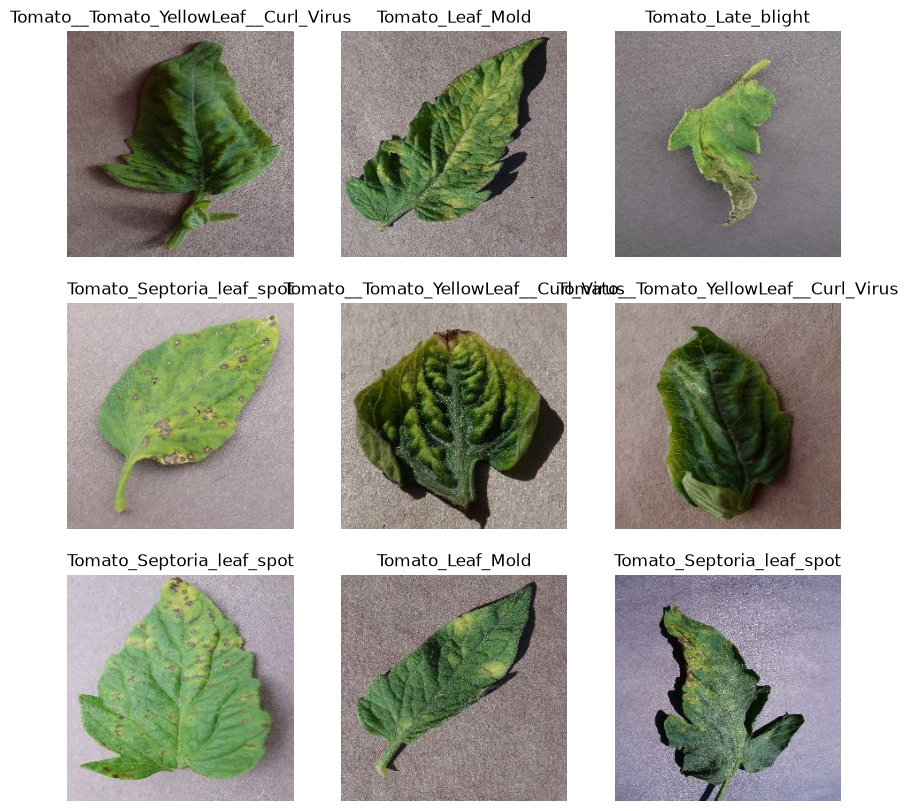

In [14]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [15]:
def get_dataset_partitions_tf(ds, ds_size, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=300):
    assert (train_split + test_split + val_split) == 1

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=20)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [16]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset,ds_size=len(dataset))

In [17]:
len(train_ds), len(val_ds), len(test_ds)

(200, 25, 26)

In [18]:
train_ds = train_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(100).prefetch(buffer_size=tf.data.AUTOTUNE)

In [19]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2)
])

In [20]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(image_size,image_size),
  layers.Rescaling(1./255)])

In [21]:
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(buffer_size=tf.data.AUTOTUNE)


In [22]:
input_shape = (batch_size, image_size, image_size, channels)
n_classes = len(class_names)
model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(16 , kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(16, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])
model.build(input_shape)

In [23]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (64, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (64, 254, 254, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (64, 127, 127, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (64, 125, 125, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (64, 62, 62, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (64, 60, 60, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (64, 30, 30, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (64, 28, 28, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (64, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (64, 12, 12, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (64, 6, 6, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (64, 4, 4, 128)        │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (64, 2, 2, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (64, 512)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, 128)              │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (64, 10)               │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,298 (1.20 MB)

 Trainable params: 314,298 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [25]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)

Epoch 1/8


/opt/homebrew/Caskroom/miniforge/base/envs/tf_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-09-28 20:42:35.921427: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-09-28 20:42:46.919698: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:11: Filling up shuffle buffer (this may take a while): 238 of 300
2026-09-28 20:42:47.481010: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2026-09-28 20:42:47.539975: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.4223 - loss: 1.6286

2026-09-28 20:44:41.432914: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:11: Filling up shuffle buffer (this may take a while): 137 of 300
2026-09-28 20:44:51.506239: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:11: Filling up shuffle buffer (this may take a while): 242 of 300
2026-09-28 20:44:51.904636: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2026-09-28 20:44:52.290907: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


200/200 ━━━━━━━━━━━━━━━━━━━━ 149s 673ms/step - accuracy: 0.4223 - loss: 1.6286 - val_accuracy: 0.6175 - val_loss: 1.0765
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 131s 637ms/step - accuracy: 0.6832 - loss: 0.9205 - val_accuracy: 0.7356 - val_loss: 0.7554
Epoch 3/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 139s 690ms/step - accuracy: 0.7476 - loss: 0.7189 - val_accuracy: 0.7506 - val_loss: 0.6782
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 146s 725ms/step - accuracy: 0.7904 - loss: 0.6003 - val_accuracy: 0.7725 - val_loss: 0.6676
Epoch 5/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 144s 718ms/step - accuracy: 0.7956 - loss: 0.6068 - val_accuracy: 0.7981 - val_loss: 0.5470
Epoch 6/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 151s 752ms/step - accuracy: 0.8180 - loss: 0.5331 - val_accuracy: 0.8375 - val_loss: 0.4850
Epoch 7/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 153s 762ms/step - accuracy: 0.7960 - loss: 0.6429 - val_accuracy: 0.7244 - val_loss: 0.8528
Epoch 8/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 146s 723ms/step - accuracy: 0.8076 - loss: 0.6118 - va

In [26]:
score = model.evaluate(test_ds)

2026-09-28 21:02:05.737937: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:11: Filling up shuffle buffer (this may take a while): 162 of 300
2026-09-28 21:02:11.615485: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2026-09-28 21:02:11.991866: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


26/26 ━━━━━━━━━━━━━━━━━━━━ 28s 378ms/step - accuracy: 0.8456 - loss: 0.4697


In [27]:
score

[0.46968874335289, 0.8455528616905212]

In [28]:
history.params

{'verbose': 'auto', 'epochs': 8, 'steps': 200}

In [29]:
acc = history.history['accuracy']
loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

Text(0.5, 0, 'epoch')

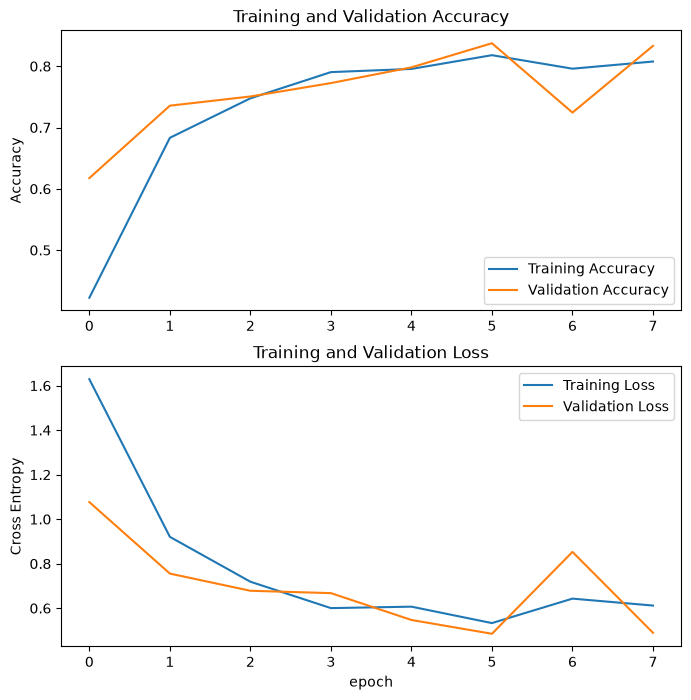

In [30]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')   

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')

First image to test
actual label: Tomato_Septoria_leaf_spot
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step 
predicted label: Tomato_Septoria_leaf_spot


2026-09-28 21:02:25.225352: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


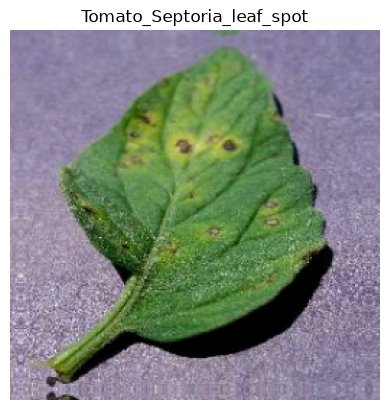

In [31]:
for image_batch, label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype('uint8')
    first_label = label_batch[0].numpy()
    
    print("First image to test")
    plt.imshow(first_image)
    plt.title(class_names[first_label])
    plt.axis('off')
    print("actual label:", class_names[first_label])

    batch_predictions = model.predict(image_batch)
    print("predicted label:", class_names[np.argmax(batch_predictions[0])])

In [32]:
def predict_image(model, image):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) 
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


2026-09-28 21:02:26.407403: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


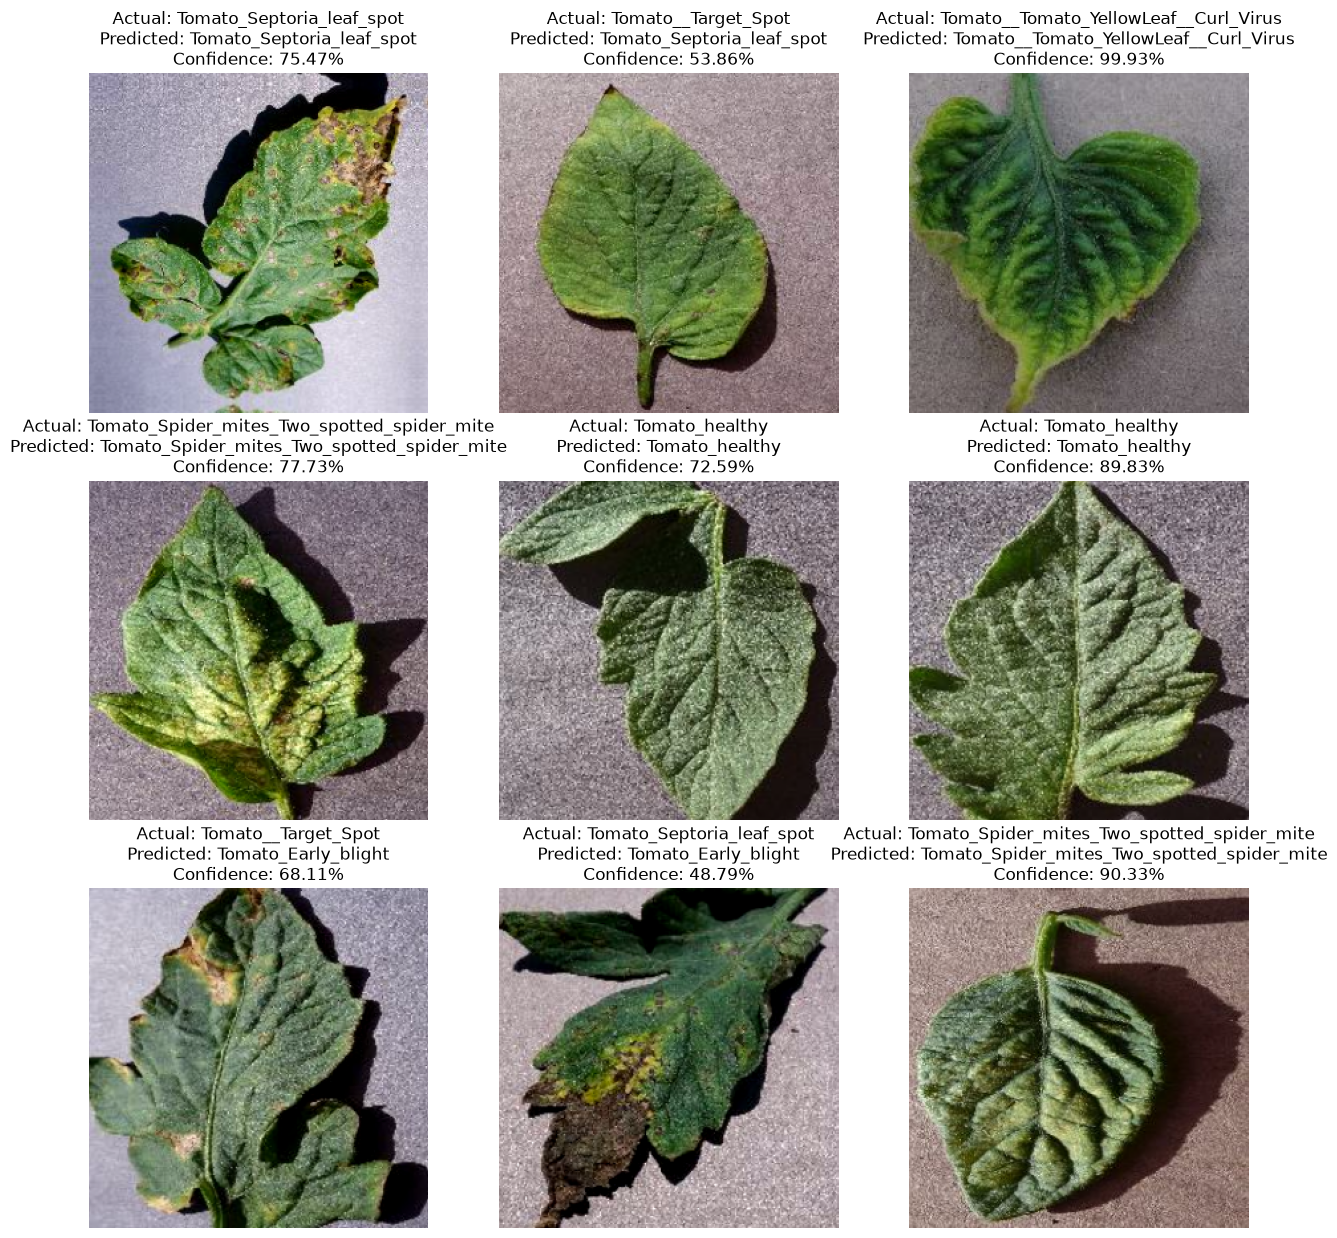

In [33]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict_image(model, images[i])
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
        plt.axis("off")

In [59]:
import os
import tensorflow as tf

# 1. Ensure the parent 'models' directory exists
os.makedirs("../models", exist_ok=True)

# 2. Automatically calculate the next version number
existing_versions = [int(i) for i in os.listdir("../models") if i.isdigit()]
model_version = max(existing_versions + [0]) + 1

# 3. Define your model path as a pure directory
model_path = f"../models/{model_version}"

# 4. Use export() instead of save() for extensionless folders
if hasattr(model, "export"):
    model.export(model_path)
else:
    tf.saved_model.save(model, model_path)

print(f"Model successfully exported to: {model_path}")

INFO:tensorflow:Assets written to: ../models/3/assets


INFO:tensorflow:Assets written to: ../models/3/assets


Model successfully exported to: ../models/3
